In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

In [2]:
df = pd.read_csv('data/har_features.csv')

META_COLS = ['session_id', 'sub_session_id', 'window_start_idx',
             'label', 'is_walking', 'is_scrolling']
feature_cols = [c for c in df.columns if c not in META_COLS]

JOINT_LABELS = ['sit_idle', 'sit_scroll', 'walk_idle', 'walk_scroll']
label_map = {(0, 0): 'sit_idle', (0, 1): 'sit_scroll',
             (1, 0): 'walk_idle', (1, 1): 'walk_scroll'}
df['joint_label'] = df.apply(
    lambda r: label_map[(r.is_walking, r.is_scrolling)], axis=1
)

print(f'{len(feature_cols)} features | {len(df)} windows')
print()
print(df['joint_label'].value_counts().rename('windows'))

116 features | 4966 windows

joint_label
sit_scroll     1393
walk_scroll    1291
walk_idle      1207
sit_idle       1075
Name: windows, dtype: int64


/tmp/ipykernel_479229/3415527734.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['joint_label'] = df.apply(


In [3]:
def evaluate_joint(clf, X, y, groups, n_splits, labels):
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    y_true_all, y_pred_all, fold_f1s = [], [], []

    for train_idx, test_idx in sgkf.split(X, y, groups=groups):
        clf.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = clf.predict(X.iloc[test_idx])
        y_true_all.extend(y.iloc[test_idx])
        y_pred_all.extend(y_pred)
        fold_f1s.append(
            f1_score(y.iloc[test_idx], y_pred, average='macro', zero_division=0)
        )

    print(f'F1 macro: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}  ({n_splits} folds)\n')
    print(classification_report(y_true_all, y_pred_all,
                                target_names=labels, zero_division=0))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true_all, y_pred_all, labels=labels),
        display_labels=labels
    ).plot(cmap='Blues', xticks_rotation=45)
    plt.tight_layout()
    plt.show()


def evaluate_multioutput(clf, X, y_df, groups, n_splits):
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    y_strat = y_df['is_walking'].astype(str) + '_' + y_df['is_scrolling'].astype(str)

    walk_true, walk_pred, scroll_true, scroll_pred, fold_f1s = [], [], [], [], []

    for train_idx, test_idx in sgkf.split(X, y_strat, groups=groups):
        clf.fit(X.iloc[train_idx], y_df.iloc[train_idx])
        preds = clf.predict(X.iloc[test_idx])

        walk_true.extend(y_df.iloc[test_idx]['is_walking'])
        scroll_true.extend(y_df.iloc[test_idx]['is_scrolling'])
        walk_pred.extend(preds[:, 0])
        scroll_pred.extend(preds[:, 1])

        joint_true = y_strat.iloc[test_idx].tolist()
        joint_pred = [f'{int(p[0])}_{int(p[1])}' for p in preds]
        fold_f1s.append(f1_score(joint_true, joint_pred, average='macro', zero_division=0))

    print(f'Joint F1 macro: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}  ({n_splits} folds)\n')
    print('── Walking ──────────────────────────────────')
    print(classification_report(walk_true, walk_pred,
                                target_names=['Sitting', 'Walking'], zero_division=0))
    print('── Scrolling ────────────────────────────────')
    print(classification_report(scroll_true, scroll_pred,
                                target_names=['Not Scrolling', 'Scrolling'], zero_division=0))

## 4-class SVM

A single RBF-SVM predicts one of the four joint activity states directly,
Inputs are the same 116 hand-crafted features as RF (But Standardized)

F1 macro: 0.855 ± 0.020  (5 folds)

              precision    recall  f1-score   support

    sit_idle       0.84      0.84      0.84      1075
  sit_scroll       0.85      0.88      0.86      1393
   walk_idle       0.88      0.83      0.86      1207
 walk_scroll       0.85      0.86      0.86      1291

    accuracy                           0.86      4966
   macro avg       0.86      0.85      0.85      4966
weighted avg       0.86      0.86      0.86      4966



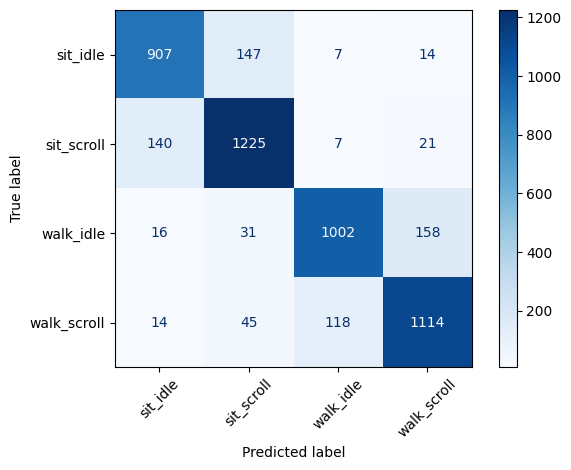

In [4]:
X      = df[feature_cols]
groups = df['sub_session_id']

clf_4class = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('svm',     SVC(kernel='rbf', C=10, gamma='scale',
                    class_weight='balanced', random_state=42)),
])

evaluate_joint(clf_4class, X, df['joint_label'], groups,
               n_splits=5, labels=JOINT_LABELS)

## Multi-output SVM

Two binary SVM classifiers share the same feature representation but are
trained and evaluated independently

In [5]:
clf_multiout = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('svm',     MultiOutputClassifier(
        SVC(kernel='rbf', C=10, gamma='scale',
            class_weight='balanced', random_state=42)
    )),
])

evaluate_multioutput(clf_multiout, X, df[['is_walking', 'is_scrolling']],
                     groups, n_splits=5)

Joint F1 macro: 0.840 ± 0.025  (5 folds)

── Walking ──────────────────────────────────
              precision    recall  f1-score   support

     Sitting       0.96      0.98      0.97      2468
     Walking       0.98      0.96      0.97      2498

    accuracy                           0.97      4966
   macro avg       0.97      0.97      0.97      4966
weighted avg       0.97      0.97      0.97      4966

── Scrolling ────────────────────────────────
               precision    recall  f1-score   support

Not Scrolling       0.87      0.82      0.85      2282
    Scrolling       0.86      0.90      0.88      2684

     accuracy                           0.86      4966
    macro avg       0.86      0.86      0.86      4966
 weighted avg       0.86      0.86      0.86      4966

